## Explorative Datenanalyse
In der explorativen Datenanalyse wurde der bereinigte Datensatz deskriptiv untersucht. Ziel war es, die Verteilung der Zielvariable Hypertonie sowie mögliche Zusammenhänge mit ausgewählten Risikofaktoren darzustellen.

Zunächst wurde geprüft, wie viele Personen und Variablen nach dem Data Cleaning im finalen Datensatz enthalten sind. Anschließend wurde die Verteilung der Zielvariable analysiert, um das Verhältnis von Personen mit und ohne Hypertonie zu beschreiben. Darüber hinaus wurden zentrale Merkmale wie Alter, Geschlecht, BMI, Taillenumfang, Rauchen, Alkoholkonsum, Vorerkrankungen und körperliche Aktivität im Zusammenhang mit Hypertonie explorativ betrachtet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv('nhanes_cleand.csv')

In [4]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6042 entries, 0 to 6041
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SEQN                     6042 non-null   float64
 1   hypertension             6042 non-null   float64
 2   high_cholesterol         6042 non-null   float64
 3   gender                   6042 non-null   str    
 4   age                      6042 non-null   float64
 5   weight(kg)               6042 non-null   float64
 6   height(cm)               6042 non-null   float64
 7   bmi                      6042 non-null   float64
 8   waist_circumference(cm)  6042 non-null   float64
 9   diabetes                 6042 non-null   float64
 10  kidney_disease           6042 non-null   float64
 11  current_smoker           6042 non-null   float64
 12  regular_alcohol_12m      6042 non-null   int64  
 13  activity_level           6042 non-null   int64  
 14  activity_level_label     6042 non-n

In [5]:
# zwischen 6.042 Teilnehmer Wie viele Teilnehmer haben Hypertonie und wie viele nicht?
df["hypertension"].value_counts(normalize=True) * 100

hypertension
0.0    61.866931
1.0    38.133069
Name: proportion, dtype: float64

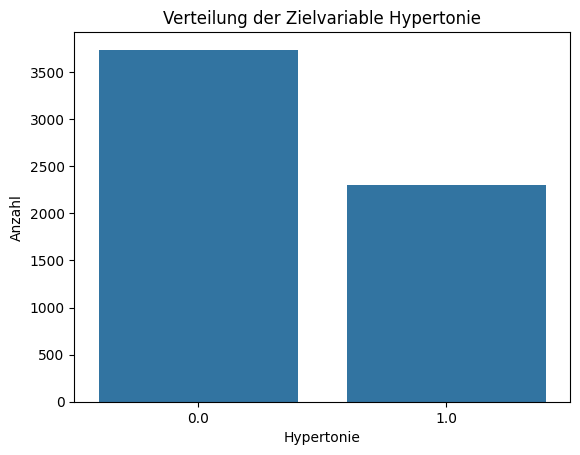

In [6]:
# die Verteilung der Zielvariable 

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="hypertension")
plt.title("Verteilung der Zielvariable Hypertonie")
plt.xlabel("Hypertonie")
plt.ylabel("Anzahl")
plt.show()

### 1. Deskriptive Statistik der numerischen Variablen:

Wie sind `Alter`, `BMI ` und `Taillenumfang` verteilt?

In [90]:
df[["age", "bmi", "waist_circumference(cm)"]].describe()

,age,bmi,waist_circumference(cm)
count,6042.000000,6042.000000,6042.000000
mean,53.836147,29.808027,101.002400
std,17.172358,7.305458,16.468283
min,20.000000,11.100000,60.000000
25%,39.000000,24.700000,89.425000
50%,57.000000,28.500000,99.500000
75%,68.000000,33.500000,110.700000
max,80.000000,74.800000,187.000000


Die deskriptive Statistik zeigt, dass der finale Datensatz 6042 Personen umfasst. Das Alter liegt zwischen 20 und 80 Jahren, mit einem Median von 57 Jahren. Der BMI weist einen Mittelwert von 29,8 und einen Median von 28,5 auf, was auf eine insgesamt erhöhte BMI-Verteilung hindeutet. Der Taillenumfang liegt im Median bei 99,5 cm. Bei BMI und Taillenumfang sind einzelne sehr hohe Werte erkennbar, die im weiteren Verlauf als mögliche extreme Werte berücksichtigt werden sollten.

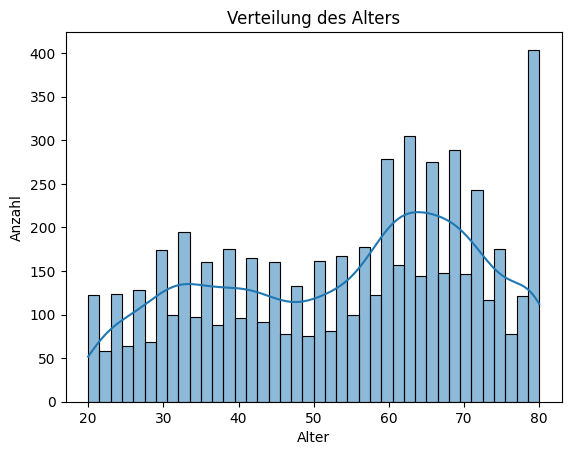

In [91]:
sns.histplot(data=df, x="age", bins=40, kde=True)
plt.title("Verteilung des Alters")
plt.xlabel("Alter")
plt.ylabel("Anzahl")
plt.show()

Die Altersverteilung zeigt, dass Personen aus einem breiten Altersbereich im Datensatz enthalten sind. Besonders die Altersgruppe zwischen etwa 50 und 70 Jahren ist stark vertreten. Da Hypertonie mit zunehmendem Alter häufiger auftritt, ist die Altersstruktur des Datensatzes für die spätere Analyse und Modellierung besonders relevant. Die ungleichmäßige Verteilung sollte bei der Interpretation der Ergebnisse berücksichtigt werden.

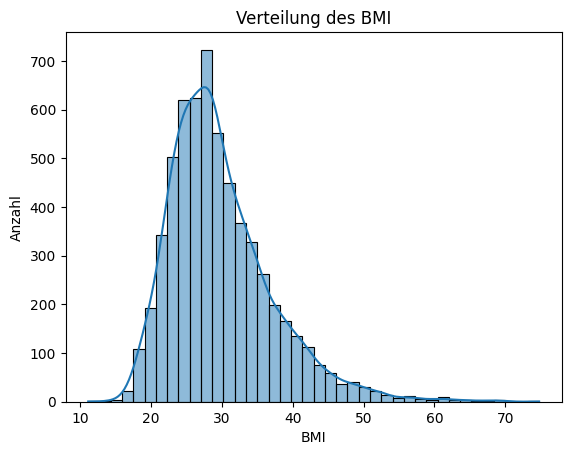

In [92]:
sns.histplot(data=df, x="bmi", bins=40, kde=True)
plt.title("Verteilung des BMI")
plt.xlabel("BMI")
plt.ylabel("Anzahl")
plt.show()

Die BMI-Verteilung ist rechtsschief. Die meisten Personen liegen im Bereich zwischen etwa 24 und 33. Einzelne sehr hohe BMI-Werte bis etwa 70 sind erkennbar und sollten als potenzielle Ausreißer bzw. extreme Werte geprüft werden. Da ein erhöhter BMI ein potenzieller Risikofaktor für Hypertonie ist, ist diese Variable für die weitere Analyse und Modellierung relevant.

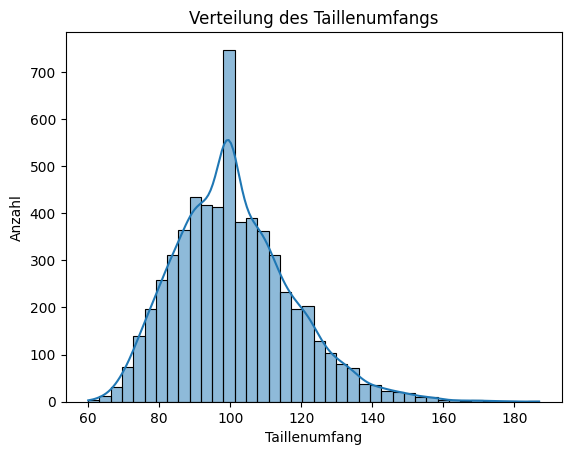

In [93]:
sns.histplot(data=df, x="waist_circumference(cm)", bins=40, kde=True)
plt.title("Verteilung des Taillenumfangs")
plt.xlabel("Taillenumfang")
plt.ylabel("Anzahl")
plt.show()

Die Verteilung des Taillenumfangs zeigt eine Häufung der Werte im Bereich von etwa 80 bis 120 cm. Der Median liegt bei 99,5 cm und der Mittelwert bei 101 cm. Die Verteilung ist leicht rechtsschief, da einzelne hohe Werte bis 187 cm vorkommen. Da ein erhöhter Taillenumfang ein potenzieller Risikofaktor für Hypertonie ist, ist diese Variable für die weitere Analyse und Modellierung relevant.

## Hypertonie nach Geschlecht

Unterscheidet sich Hypertonie zwischen Männern und Frauen?

In [9]:
gender_hyp = pd.crosstab(
    df["gender"],
    df["hypertension"],
    normalize="index"
) * 100

gender_hyp.round(2)

hypertension,0.0,1.0
gender,,
Female,63.02,36.98
Male,60.45,39.55


Die prozentuale Auswertung zeigt, dass der Anteil der Personen mit Hypertonie bei Männern mit 39,55 % etwas höher ist als bei Frauen mit 36,98 %. In beiden Gruppen überwiegt jedoch der Anteil der Personen ohne Hypertonie. Der Unterschied zwischen den Geschlechtern ist eher gering und sollte daher vorsichtig interpretiert werden.

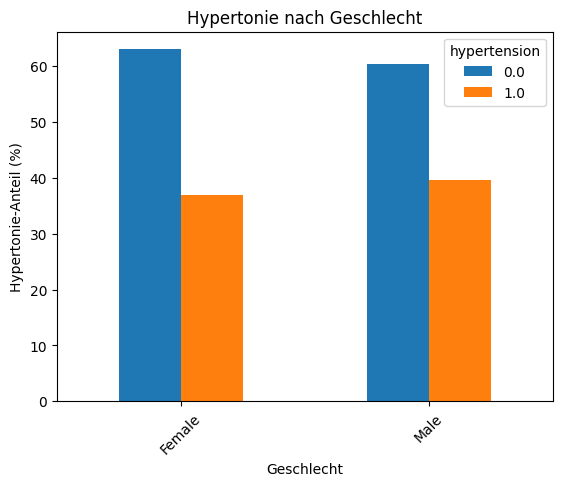

In [10]:
gender_hyp.plot(kind="bar")

plt.title('Hypertonie nach Geschlecht')
plt.xlabel('Geschlecht')
plt.ylabel('Hypertonie-Anteil (%)')
plt.xticks(rotation=45)
plt.show()


**Fazit**:
Geschlecht kann als Feature aufgenommen werden, aber der beobachtete Unterschied ist relativ gering. Wahrscheinlich werden Variablen wie Alter, BMI und Taillenumfang für die Vorhersage stärker relevant sein.

## Hypertonie nach Altersgruppen

Steigt der Anteil von Hypertonie mit dem Alter?

In [11]:
age_hyp = pd.crosstab(
    df["age_category"],
    df["hypertension"],
    normalize="index"
) * 100


age_hyp.round(2)

hypertension,0.0,1.0
age_category,,
20-29,93.54,6.46
30-39,86.06,13.94
40-49,74.81,25.19
50-59,56.61,43.39
60+,44.51,55.49


In [12]:
age_order = ["20-29", "30-39", "40-49", "50-59", "60+"]
age_hyp = (
    df.groupby("age_category")["hypertension"]
    .mean()
    .reindex(age_order)
    * 100
)

age_hyp.round(2)

age_category
20-29     6.46
30-39    13.94
40-49    25.19
50-59    43.39
60+      55.49
Name: hypertension, dtype: float64

Die Auswertung nach Altersgruppen zeigt einen deutlichen **Anstieg** des Hypertonie-Anteils mit **zunehmendem Alter**. Während in der Altersgruppe 20–29 nur 6,46 % eine Hypertonie aufweisen, liegt der Anteil in der Gruppe 60+ bei 55,49 %. Besonders ab der Altersgruppe 40–49 steigt der Anteil deutlich an. Dies spricht dafür, dass Alter ein wichtiger Prädiktor für Hypertonie ist und in der späteren Modellierung berücksichtigt werden sollte.

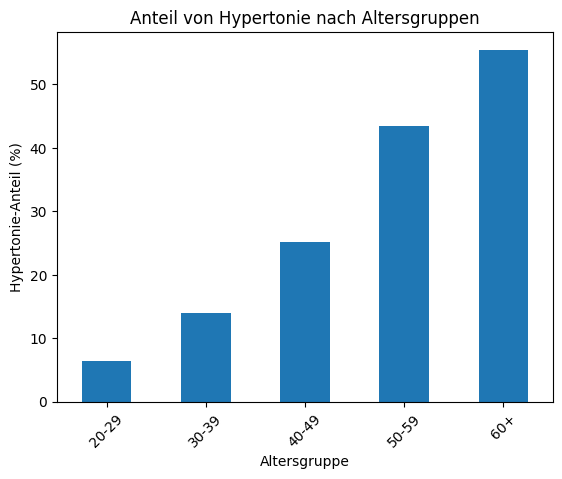

In [99]:
age_hyp.plot(kind="bar")

plt.title("Anteil von Hypertonie nach Altersgruppen")
plt.xlabel("Altersgruppe")
plt.ylabel("Hypertonie-Anteil (%)")
plt.xticks(rotation=45)
plt.show()

## Hypertonie nach BMI

Unterscheidet sich die BMI-Kategorien zwischen Personen mit Hypertonie?

In [13]:
bmi_order = ["underweight", "normal_weight", "overweight", "obesity"]
bmi_hyp = (
    df.groupby("bmi_category")["hypertension"]
    .mean()
    .reindex(bmi_order)
    * 100
)

bmi_hyp.round(2)

bmi_category
underweight      14.94
normal_weight    24.92
overweight       36.53
obesity          48.41
Name: hypertension, dtype: float64

In [101]:
df.groupby("hypertension")["bmi"].describe()

,count,mean,std,min,25%,50%,75%,max
hypertension,,,,,,,,
0.0,3738.0,28.613724,6.811909,11.1,23.900,27.4,31.8,74.8
1.0,2304.0,31.745660,7.656881,15.2,26.475,30.2,35.5,68.9


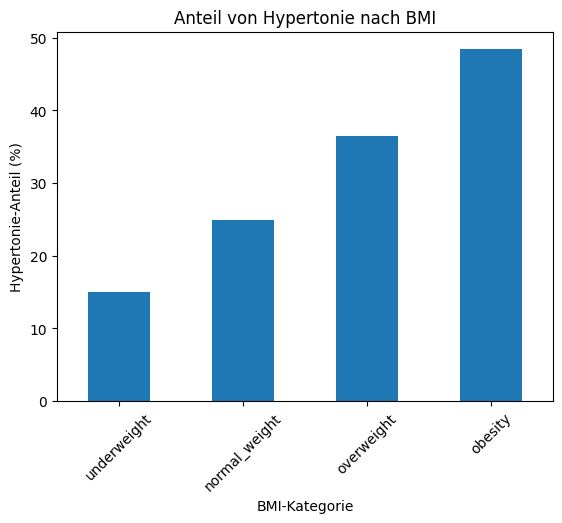

In [102]:
bmi_hyp.plot(kind="bar")

plt.title("Anteil von Hypertonie nach BMI")
plt.xlabel("BMI-Kategorie")
plt.ylabel("Hypertonie-Anteil (%)")
plt.xticks(rotation= 45)
plt.show()

Die Auswertung nach BMI-Kategorien zeigt, ob der Hypertonie-Anteil mit zunehmender BMI-Kategorie steigt. Wenn Personen mit Übergewicht oder Adipositas einen höheren Hypertonie-Anteil aufweisen als Personen mit Normalgewicht, spricht dies für einen Zusammenhang zwischen erhöhtem BMI und Hypertonie. Für die Modellierung kann BMI daher als relevantes numerisches Feature berücksichtigt werden.

## Hypertonie nach Taillenumfang
Unterscheidet sich der Taillenumfang zwischen Personen mit Hypertonie?

In [103]:
df.groupby("hypertension")["waist_circumference(cm)"].describe()

,count,mean,std,min,25%,50%,75%,max
hypertension,,,,,,,,
0.0,3738.0,97.589219,15.569622,60.0,86.5,96.7,106.575,177.7
1.0,2304.0,106.539931,16.384574,64.2,96.0,104.7,116.300,187.0


Bei Personen ohne Hypertonie liegt der Median des Taillenumfangs ungefähr bei etwa 97 cm. Bei Personen mit Hypertonie liegt der Median ungefähr bei 105 cm.

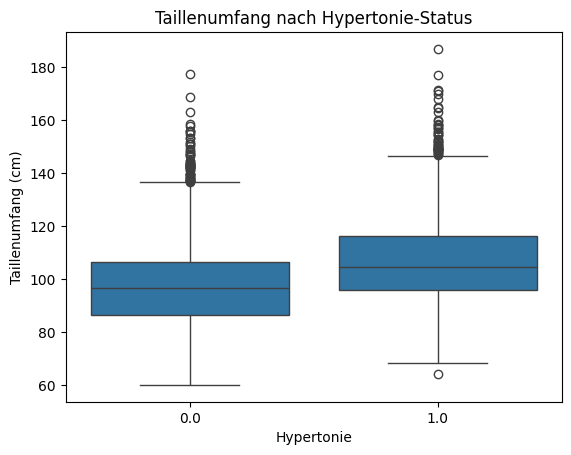

In [104]:
sns.boxplot(data=df, x="hypertension", y="waist_circumference(cm)")
plt.title("Taillenumfang nach Hypertonie-Status")
plt.xlabel("Hypertonie")
plt.ylabel("Taillenumfang (cm)")
plt.show()

Der Boxplot zeigt, dass Personen mit Hypertonie im Median einen höheren Taillenumfang aufweisen als Personen ohne Hypertonie. Auch der mittlere Wertebereich liegt bei der Hypertonie-Gruppe insgesamt höher. Dies deutet darauf hin, dass ein höherer Taillenumfang mit Hypertonie assoziiert sein kann. In beiden Gruppen sind einzelne hohe Werte erkennbar, die als mögliche extreme Werte berücksichtigt werden sollten.

### Hypertonie nach lebensstilbezogenen Risikofaktoren:
#### 1. Rausstatus 
Es wurde untersucht, ob sich der Anteil der Personen mit Hypertonie zwischen Raucherinnen bzw. Rauchern unterscheidet. 

In [105]:
smoke_hyp = (
    df.groupby("current_smoker")["hypertension"]
    .mean()
    * 100
)

smoke_hyp.round(2)

current_smoker
0.0    37.77
1.0    40.20
Name: hypertension, dtype: float64

([<matplotlib.axis.XTick at 0x125a55a1820>,
 [Text(0, 0, 'Nichtraucher'), Text(1, 0, 'Raucher')])

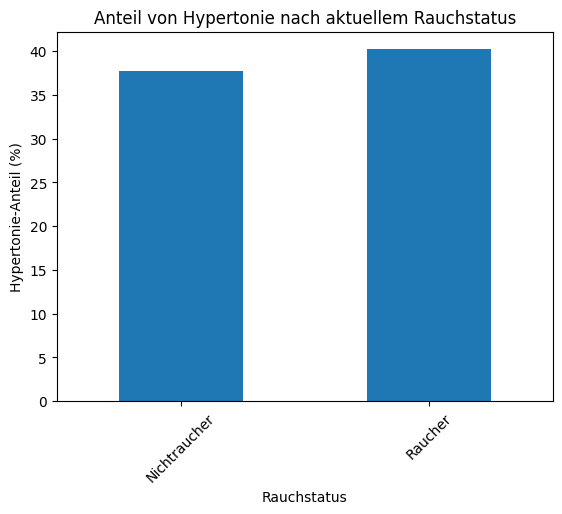

In [106]:
smoke_hyp.plot(kind="bar")

plt.title("Anteil von Hypertonie nach aktuellem Rauchstatus")
plt.xlabel("Rauchstatus")
plt.ylabel("Hypertonie-Anteil (%)")
plt.xticks(rotation= 45)

plt.xticks([0, 1], ["Nichtraucher", "Raucher"])

Der Anteil der Personen mit Hypertonie ist bei aktuellen Rauchern etwas höher als bei Nicht-Rauchern. Der Unterschied fällt jedoch relativ gering aus. Da es sich um eine deskriptive Analyse handelt, kann daraus kein kausaler Zusammenhang abgeleitet werden. Weitere Einflussfaktoren wie Alter, BMI, Geschlecht oder Vorerkrankungen müssen im Modell gemeinsam berücksichtigt werden.

#### 2. Alkoholkonsum 

Die Variable regular_alcohol_12m beschreibt, ob in den letzten zwölf Monaten Alkoholkonsum berichtet wurde. Für die grafische Darstellung wurden die Kategorien als „kein Alkoholkonsum“ und „Alkoholkonsum in den letzten 12 Monaten“ bezeichnet.

In [15]:

alc_hyp = (
    df.groupby("regular_alcohol_12m")["hypertension"]
    .mean()
    * 100
)

alc_hyp.round(2)

regular_alcohol_12m
0    40.27
1    33.11
Name: hypertension, dtype: float64

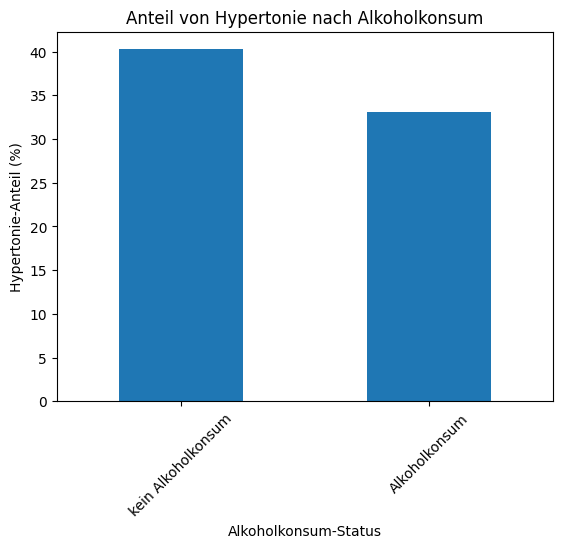

In [16]:
alc_hyp.plot(kind="bar")

plt.title("Anteil von Hypertonie nach Alkoholkonsum")
plt.xlabel("Alkoholkonsum-Status")
plt.ylabel("Hypertonie-Anteil (%)")
plt.xticks(rotation= 45)

plt.xticks([0, 1], ["kein Alkoholkonsum", "Alkoholkonsum"]) 
plt.show()

In [109]:
df.groupby("regular_alcohol_12m").agg(
    n=("hypertension", "size"),
    hypertension_rate=("hypertension", "mean"),
    mean_age=("age", "mean"),
    mean_bmi=("bmi", "mean"),
    mean_waist =("waist_circumference(cm)", "mean")
)

,n,hypertension_rate,mean_age,mean_bmi,mean_waist
regular_alcohol_12m,,,,,
0,4239,0.402689,54.230715,30.347488,101.778250
1,1803,0.331115,52.908486,28.539712,99.178314


Die Variable `regular_alcohol_12m` zeigte in der deskriptiven Analyse keinen eindeutig positiven Zusammenhang mit Hypertonie. Personen ohne regelmäßigen Alkoholkonsum in den letzten zwölf Monaten wiesen einen höheren Hypertonieanteil auf als Personen mit regelmäßigem Alkoholkonsum in diesem Zeitraum. Dieser Befund wurde jedoch vorsichtig interpretiert, da die Gruppe ohne regelmäßigen Alkoholkonsum im Durchschnitt älter war und einen höheren BMI aufwies. Da Alter und BMI zentrale Risikofaktoren für Hypertonie sind, kann der beobachtete Unterschied durch Confounding beeinflusst sein.

Zusätzlich ist zu berücksichtigen, dass die Gruppe ohne regelmäßigen Alkoholkonsum auch ehemalige Alkoholkonsumentinnen und -konsumenten enthalten kann. Personen, die früher Alkohol konsumiert haben, können den Konsum beispielsweise aufgrund gesundheitlicher Beschwerden, ärztlicher Empfehlungen oder Medikamenteneinnahme reduziert oder beendet haben. Dadurch kann der Hypertonieanteil in dieser Gruppe erhöht erscheinen, ohne dass daraus ein schützender Effekt von regelmäßigem Alkoholkonsum abgeleitet werden darf.

Aus diesem Grund wurde die Alkoholvariable nicht isoliert als direkter Risikofaktor interpretiert, sondern im weiteren Modellvergleich darauf geprüft, ob sie einen zusätzlichen Beitrag zur Vorhersageleistung des Modells leistet.


#### Aktivitätslevel und Sitzzeit

In [110]:
activity_summary = (
    df.groupby("activity_level_label")
    .agg(
        n=("hypertension", "count"),
        hypertonie_anteil=("hypertension", "mean"),
        mittlere_sitzzeit=("sitting_hours_per_day", "mean"),
        median_sitzzeit=("sitting_hours_per_day", "median")
    )
)

activity_summary["hypertonie_anteil"] = activity_summary["hypertonie_anteil"] * 100

activity_summary.round(2)

,n,hypertonie_anteil,mittlere_sitzzeit,median_sitzzeit
activity_level_label,,,,
intensiv aktiv,2701,28.40,5.94,5.0
moderat aktiv,2175,43.77,6.08,5.0
nicht aktiv,1166,50.17,6.70,6.0


Die deskriptive Analyse zeigt einen deutlichen Zusammenhang zwischen Aktivitätslevel und Hypertonie-Anteil. Während intensiv aktive Personen einen Hypertonie-Anteil von 28,4 % aufweisen, liegt dieser Anteil bei moderat aktiven Personen bei 43,77 % und bei nicht aktiven Personen bei 50,17 %. Zusätzlich zeigt sich, dass nicht aktive Personen im Durchschnitt eine etwas höhere tägliche Sitzzeit aufweisen. Die Ergebnisse deuten darauf hin, dass körperliche Aktivität in diesem Datensatz mit einem niedrigeren Hypertonie-Anteil verbunden ist. Da es sich um eine deskriptive Analyse handelt, können jedoch keine kausalen Aussagen getroffen werden.

#### Vorerkrankungen und Hypertonie


In [18]:
pre_existing_conditions = ["diabetes", "kidney_disease", "high_cholesterol"]

condition_summary = []

for col in pre_existing_conditions:
    temp = (
        df.groupby(col)["hypertension"]
        .agg(
            n="count",
            hypertonie_anteil="mean"
        )
        .reset_index()
    )
    
    temp["hypertonie_anteil"] = temp["hypertonie_anteil"] * 100
    temp["vorerkrankung"] = col
    
    temp = temp.rename(columns={col: "status"})
    
    condition_summary.append(temp)

condition_summary = pd.concat(condition_summary, ignore_index=True)

condition_summary.round(2)

,status,n,hypertonie_anteil,vorerkrankung
0,0.0,5177,32.43,diabetes
1,1.0,865,72.25,diabetes
2,0.0,5811,36.59,kidney_disease
3,1.0,231,77.06,kidney_disease
4,0.0,3552,24.61,high_cholesterol
5,1.0,2490,57.43,high_cholesterol


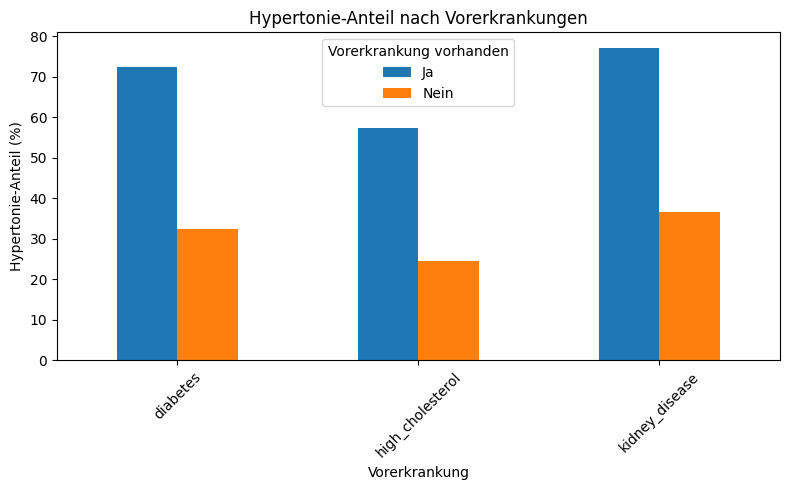

In [19]:

condition_summary ["status"] = condition_summary ["status"].replace({
    0: "Nein",
    1: "Ja"
})

# Einfaches gruppiertes Balkendiagramm
condition_summary .pivot(
    index="vorerkrankung",
    columns="status",
    values="hypertonie_anteil"
).plot(kind="bar", figsize=(8, 5))

plt.title("Hypertonie-Anteil nach Vorerkrankungen")
plt.xlabel("Vorerkrankung")
plt.ylabel("Hypertonie-Anteil (%)")
plt.xticks(rotation=45)
plt.legend(title="Vorerkrankung vorhanden")
plt.tight_layout()
plt.show()

Die deskriptive Analyse zeigt deutliche Unterschiede im Hypertonie-Anteil nach bestehenden Vorerkrankungen. Personen mit Diabetes, Nierenerkrankung oder erhöhtem Cholesterinwert weisen deutlich höhere Hypertonie-Anteile auf als Personen ohne diese Erkrankungen. Besonders hoch ist der Anteil bei Personen mit Nierenerkrankung und Diabetes. Die Ergebnisse sind jedoch deskriptiv zu interpretieren, da weitere Einflussfaktoren wie Alter, BMI oder Geschlecht nicht kontrolliert wurden. Aufgrund der vergleichsweise kleinen Fallzahl in der Gruppe mit Nierenerkrankung sollte dieses Ergebnis vorsichtig interpretiert werden.

### Korrelationsanalyse numerischer Variablen

Wie hängen numerische Variablen miteinander zusammen?

Die Spearman-Korrelation wird verwendet, um monotone Zusammenhänge zwischen numerischen Variablen zu untersuchen.

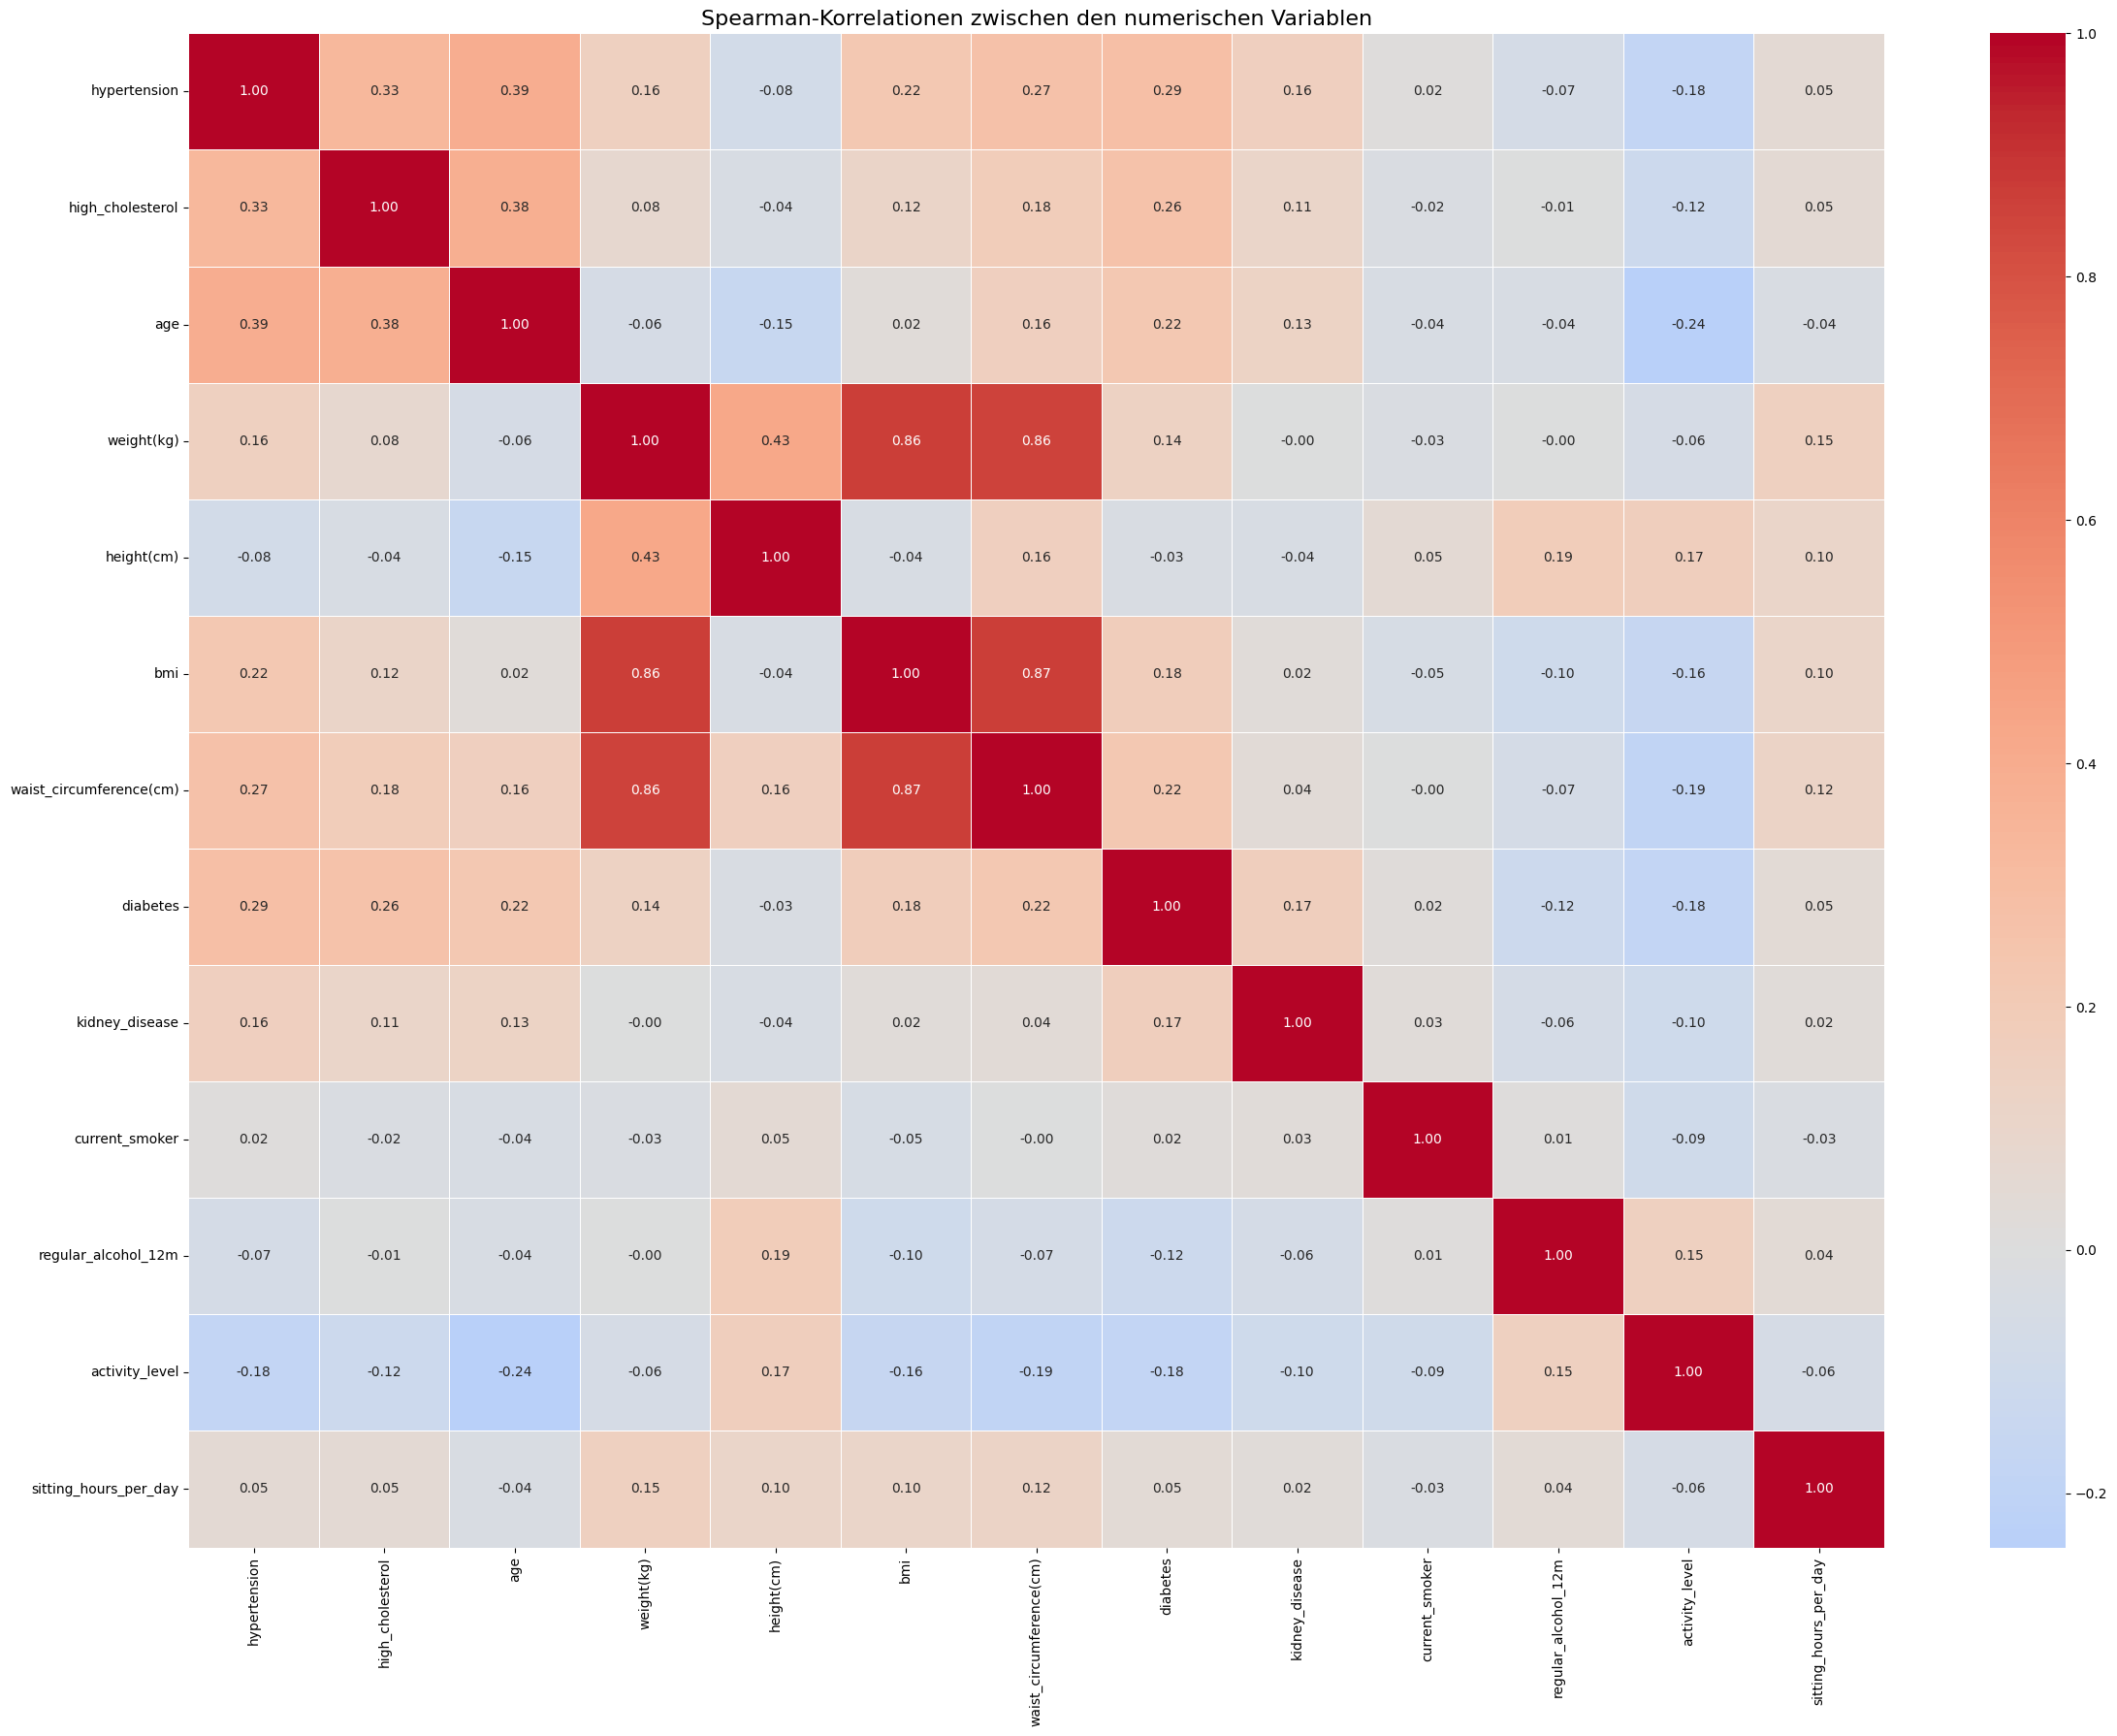

In [20]:
# Kopie des Datensatzes für die Korrelationsanalyse erstellen
df_graph = df.copy()

# Teilnehmer-ID entfernen, da sie keine inhaltliche Variable ist
df_graph = df_graph.drop(columns=["SEQN"], errors="ignore")

# Spearman-Korrelationsmatrix für numerische Variablen berechnen
corr_matrix = df_graph.corr(
    numeric_only=True,
    method="spearman"
)

# Heatmap der Korrelationsmatrix erstellen
plt.figure(figsize=(24, 18))

sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt=".2f",         
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Spearman-Korrelationen zwischen den numerischen Variablen", fontsize=16)
plt.tight_layout()
plt.show()

In [114]:
corr_matrix.round(2)

#Spearman-r	Stärke
#0.00 bis 0.19	sehr schwach
#0.20 bis 0.39	schwach
##0.40 bis 0.59	moderat
#0.60 bis 0.79	stark
#0.80 bis 1.00	sehr stark

,SEQN,hypertension,high_cholesterol,age,weight(kg),height(cm),bmi,waist_circumference(cm),diabetes,kidney_disease,current_smoker,regular_alcohol_12m,activity_level,sitting_hours_per_day
SEQN,1.00,0.01,-0.00,0.01,-0.01,-0.03,-0.00,-0.00,-0.00,-0.01,-0.01,0.02,0.00,0.02
hypertension,0.01,1.00,0.33,0.39,0.16,-0.08,0.22,0.27,0.29,0.16,0.02,-0.07,-0.18,0.05
high_cholesterol,-0.00,0.33,1.00,0.38,0.08,-0.04,0.12,0.18,0.26,0.11,-0.02,-0.01,-0.12,0.05
age,0.01,0.39,0.38,1.00,-0.06,-0.15,0.02,0.16,0.22,0.13,-0.04,-0.04,-0.24,-0.04
weight(kg),-0.01,0.16,0.08,-0.06,1.00,0.43,0.86,0.86,0.14,-0.00,-0.03,-0.00,-0.06,0.15
height(cm),-0.03,-0.08,-0.04,-0.15,0.43,1.00,-0.04,0.16,-0.03,-0.04,0.05,0.19,0.17,0.10
bmi,-0.00,0.22,0.12,0.02,0.86,-0.04,1.00,0.87,0.18,0.02,-0.05,-0.10,-0.16,0.10
waist_circumference(cm),-0.00,0.27,0.18,0.16,0.86,0.16,0.87,1.00,0.22,0.04,-0.00,-0.07,-0.19,0.12
diabetes,-0.00,0.29,0.26,0.22,0.14,-0.03,0.18,0.22,1.00,0.17,0.02,-0.12,-0.18,0.05
kidney_disease,-0.01,0.16,0.11,0.13,-0.00,-0.04,0.02,0.04,0.17,1.00,0.03,-0.06,-0.10,0.02


### Kurze Zusammenfassung der EDA-Ergebnisse

Die Spearman-Korrelationsmatrix wurde verwendet, um Zusammenhänge zwischen numerischen Variablen zu untersuchen. Der stärkste positive Zusammenhang mit Hypertonie zeigte sich für das Alter. Weitere positive Zusammenhänge bestanden mit hohem Cholesterinwert, Diabetes, Taillenumfang und BMI. Das Aktivitätslevel zeigte einen negativen Zusammenhang mit Hypertonie, was mit den vorherigen deskriptiven Ergebnissen übereinstimmt. Sehr starke Korrelationen zeigten sich zwischen Gewicht, BMI und Taillenumfang, was auf mögliche Multikollinearität hinweist. Diese Variablen sollten daher bei der späteren Modellierung nicht unkritisch gemeinsam verwendet werden. Die Variablen Sitzzeit und aktueller Rauchstatus zeigten nur sehr schwache Zusammenhänge mit Hypertonie.